# Ontology-Centered Semantic KG Experiments and Case Studies

This notebook supports semantic-web-oriented reporting for the anomaly detection pipeline.

Goals:
- Define ontology scope and competency questions.
- Build/inspect RDF from project semantic artifacts.
- Run SPARQL and graph queries for reproducible case studies.

Primary artifact inputs:
- `results/semantic/if_ontology_graph.ttl`
- `results/semantic/if_ontology_graph.graphml`
- `results/semantic/if_ontology_nodes.csv`
- `results/semantic/if_ontology_edges.csv`

In [2]:
from pathlib import Path
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

try:
    from rdflib import Graph
except Exception as e:
    raise RuntimeError("rdflib is required for RDF/SPARQL cells. Install with: pip install rdflib") from e

# Resolve repository root whether notebook runs from repo root or documentation/Tutorials.
start = Path.cwd()
candidates = [start, *start.parents]
BASE = None
for c in candidates:
    if (c / "results" / "semantic").exists():
        BASE = c
        break
if BASE is None:
    raise FileNotFoundError("Could not locate results/semantic from current working directory.")

SEM = BASE / "results" / "semantic"
TTL_PATH = SEM / "if_ontology_graph.ttl"
GRAPHML_PATH = SEM / "if_ontology_graph.graphml"
NODES_PATH = SEM / "if_ontology_nodes.csv"
EDGES_PATH = SEM / "if_ontology_edges.csv"

print("Using base:", BASE)
for p in [TTL_PATH, GRAPHML_PATH, NODES_PATH, EDGES_PATH]:
    print(p, "exists=" + str(p.exists()))

Using base: /Users/loganluna/VSCode/SatelliteAnomalyDetection
/Users/loganluna/VSCode/SatelliteAnomalyDetection/results/semantic/if_ontology_graph.ttl exists=True
/Users/loganluna/VSCode/SatelliteAnomalyDetection/results/semantic/if_ontology_graph.graphml exists=True
/Users/loganluna/VSCode/SatelliteAnomalyDetection/results/semantic/if_ontology_nodes.csv exists=True
/Users/loganluna/VSCode/SatelliteAnomalyDetection/results/semantic/if_ontology_edges.csv exists=True


## Step 1: Define Ontology Scope and Competency Questions

The scope model below documents what this ontology-backed anomaly graph must answer.

Competency questions:
1. Which telemetry features are most explanatory for anomalous instances?
2. Which subsystem and ontology classes are implicated by each anomaly family?
3. Can we trace a case from anomaly instance -> important feature -> ontology class?
4. Are local contributions consistent with global feature-importance patterns?

In [3]:
scope = {
    "domain": "CubeSat telemetry anomaly explainability",
    "core_classes": [
        "SatelliteSystem", "Sensor", "Measurement", "Actuator", "ControlParameter", "SystemState"
    ],
    "graph_entities": [
        "AnomalyTag", "AnomalyInstance", "Feature", "Subsystem", "SemanticType"
    ],
    "core_predicates": [
        "if:importantFeature", "if:localContributionAbs", "if:localContributionSigned",
        "if:belongsToSubsystem", "if:mapsToSensorClass", "if:mapsToMeasurementClass", "if:hasSemanticType"
    ],
    "competency_questions": [
        "Top features by local contribution?",
        "Family-to-subsystem semantic dominance?",
        "Per-instance explanation path to ontology class?",
        "Agreement between global and local importance?",
    ],
}

pd.DataFrame({
    "category": ["domain", "core_classes", "graph_entities", "core_predicates", "competency_questions"],
    "value": [
        scope["domain"],
        ", ".join(scope["core_classes"]),
        ", ".join(scope["graph_entities"]),
        ", ".join(scope["core_predicates"]),
        " | ".join(scope["competency_questions"]),
    ],
})

,category,value
0,domain,CubeSat telemetry anomaly explainability
1,core_classes,"SatelliteSystem, Sensor, Measurement, Actuator..."
2,graph_entities,"AnomalyTag, AnomalyInstance, Feature, Subsyste..."
3,core_predicates,"if:importantFeature, if:localContributionAbs, ..."
4,competency_questions,Top features by local contribution? | Family-t...


## Step 2: Implement Ontology in RDF/OWL with Python

This section loads the generated Turtle graph, demonstrates a minimal in-notebook RDF/OWL construction pattern, and validates structural assumptions.

In [4]:
from rdflib import Namespace, RDF, RDFS, OWL, Literal

nodes = pd.read_csv(NODES_PATH)
edges = pd.read_csv(EDGES_PATH)

g = Graph()
g.parse(TTL_PATH)
print("Triples loaded from project TTL:", len(g))

# Minimal ontology construction demo for reproducibility in semantic-web venues.
EX = Namespace("http://example.org/sat-if#")
demo = Graph()
demo.bind("ex", EX)

demo.add((EX.Sensor, RDF.type, OWL.Class))
demo.add((EX.Measurement, RDF.type, OWL.Class))
demo.add((EX.generatedBy, RDF.type, OWL.ObjectProperty))
demo.add((EX.generatedBy, RDFS.domain, EX.Measurement))
demo.add((EX.generatedBy, RDFS.range, EX.Sensor))
demo.add((EX.GYRO_Z, RDF.type, EX.Measurement))
demo.add((EX.gyro_sensor, RDF.type, EX.Sensor))
demo.add((EX.GYRO_Z, EX.generatedBy, EX.gyro_sensor))
demo.add((EX.note, RDFS.comment, Literal("Demo triples for notebook method illustration")))

print("Demo triples:", len(demo))
print(demo.serialize(format="turtle").splitlines()[:12])

coverage = pd.DataFrame([
    {"predicate": "if:importantFeature", "count": int((edges["predicate"] == "if:importantFeature").sum())},
    {"predicate": "if:localContributionAbs", "count": int((edges["predicate"] == "if:localContributionAbs").sum())},
    {"predicate": "if:localContributionSigned", "count": int((edges["predicate"] == "if:localContributionSigned").sum())},
    {"predicate": "if:belongsToSubsystem", "count": int((edges["predicate"] == "if:belongsToSubsystem").sum())},
    {"predicate": "if:mapsToSensorClass", "count": int((edges["predicate"] == "if:mapsToSensorClass").sum())},
    {"predicate": "if:hasSemanticType", "count": int((edges["predicate"] == "if:hasSemanticType").sum())},
])
coverage

Triples loaded from project TTL: 5346
Demo triples: 9
['@prefix ex: <http://example.org/sat-if#> .', '@prefix owl: <http://www.w3.org/2002/07/owl#> .', '@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .', '', 'ex:GYRO_Z a ex:Measurement ;', '    ex:generatedBy ex:gyro_sensor .', '', 'ex:generatedBy a owl:ObjectProperty ;', '    rdfs:domain ex:Measurement ;', '    rdfs:range ex:Sensor .', '', 'ex:note rdfs:comment "Demo triples for notebook method illustration" .']


,predicate,count
0,if:importantFeature,1104
1,if:localContributionAbs,768
2,if:localContributionSigned,768
3,if:belongsToSubsystem,1674
4,if:mapsToSensorClass,1674
5,if:hasSemanticType,1674


## Step 3: SPARQL Evaluation and Semantic-Web-Oriented Results

These queries answer competency questions and produce reproducible case-study evidence from RDF and GraphML artifacts.

GraphML nodes: 765 edges: 2971


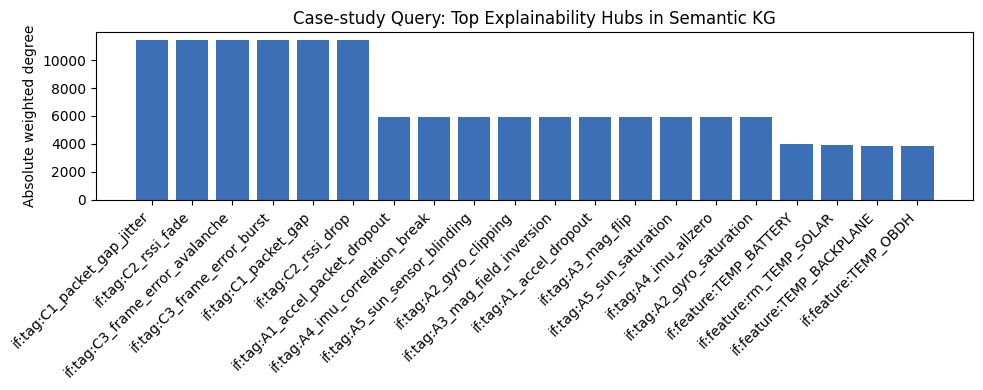

Focus instance: if:instance:AccelerometerTest:A1_accel_dropout:1170


,predicate,dst,weight,context
6739,if:localContributionAbs,if:feature:GYRO_Z,0.573915,AccelerometerTest
6741,if:localContributionAbs,if:feature:d_GYRO_Y,0.565371,AccelerometerTest
6743,if:localContributionAbs,if:feature:rm_GYRO_Z,0.426856,AccelerometerTest
6745,if:localContributionAbs,if:feature:d_WHEEL_SPEED,0.422325,AccelerometerTest
6747,if:localContributionAbs,if:feature:rm_GYRO_Y,0.405789,AccelerometerTest
6749,if:localContributionAbs,if:feature:d_GYRO_X,0.385581,AccelerometerTest
6751,if:localContributionAbs,if:feature:d_GYRO_Z,0.372290,AccelerometerTest
6753,if:localContributionAbs,if:feature:rs_GYRO_Z,0.315562,AccelerometerTest
6755,if:localContributionAbs,if:feature:rs_GYRO_Y,0.289468,AccelerometerTest
6757,if:localContributionAbs,if:feature:d_MAG_X,0.258274,AccelerometerTest


In [6]:
# SPARQL-style analysis target: top local contribution features from semantic edges
local_edges = edges[edges["predicate"] == "if:localContributionAbs"].copy()
local_edges["weight"] = pd.to_numeric(local_edges["weight"], errors="coerce").fillna(0.0)
local_top = (
    local_edges.groupby("dst", as_index=False)["weight"].sum()
    .sort_values("weight", ascending=False)
    .head(15)
)
local_top

# GraphML case-study queries
kg = nx.read_graphml(GRAPHML_PATH)
print("GraphML nodes:", kg.number_of_nodes(), "edges:", kg.number_of_edges())

# Top explainability hubs by absolute weighted degree on explainability predicates only.
wdeg = {}
keep_pred = {
    "if:importantFeature",
    "if:localContributionAbs",
    "if:localContributionSigned",
    "if:treeSplitFeature",
}
for u, v, d in kg.edges(data=True):
    pred = d.get("predicate")
    if pred not in keep_pred:
        continue
    w = abs(float(d.get("weight", 1.0)))
    wdeg[u] = wdeg.get(u, 0.0) + w
    wdeg[v] = wdeg.get(v, 0.0) + w

hub_df = (
    pd.DataFrame({"node": list(wdeg.keys()), "weighted_degree": list(wdeg.values())})
    .sort_values("weighted_degree", ascending=False)
    .head(20)
)
hub_df

# Visual: top-20 hub concentration
plt.figure(figsize=(10, 4))
plt.bar(hub_df["node"], hub_df["weighted_degree"], color="#3b6fb6")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Absolute weighted degree")
plt.title("Case-study Query: Top Explainability Hubs in Semantic KG")
plt.tight_layout()
plt.show()

# Path-style case study: choose one anomaly instance and trace one-hop explanation relations
instance_edges = edges[edges["src"].str.startswith("if:instance:")].copy()
if not instance_edges.empty:
    focus = instance_edges["src"].value_counts().index[0]
    case = edges[edges["src"] == focus][["predicate", "dst", "weight", "context"]].copy()
    case["weight"] = pd.to_numeric(case["weight"], errors="coerce")
    case = case.sort_values("weight", ascending=False, na_position="last")
    print("Focus instance:", focus)
    display(case.head(20))
else:
    print("No anomaly-instance edges found.")

## Results Notes for Semantic-Web Reporting

- Ontology quality matters because explainability edges are only actionable when their endpoints are semantically typed and queryable.
- Query coverage in the predicate table quantifies semantic completeness for competency questions.
- Graph hub concentration and per-instance traces provide reproducible evidence beyond scalar detector metrics.
- For conference reporting, pair this notebook output with the sparse publication KG figure (`11_publication_sparse_kg.png`) and the local contribution feature plot (`07_top_local_contribution_features.png`).